# Non-unitary dynamics with LCHS: a pulse carried and spread by a flow

A dye pulse circulates in a closed channel, carried by the flow and spread by diffusion, and on 8 grid points its concentration solves the linear ODE $du/dt=-Au$. This notebook computes $u(T)$ with NWQLib's Linear Combination of Hamiltonian Simulation (LCHS) on a quantum circuit and checks it against `scipy.linalg.expm`.

Install with `python -m pip install -e ".[aer,notebook,tensor]"` from the repository root · at most 12 simulated qubits · about 30 s on a laptop.

> **How to read this notebook.** The next cells solve the channel and show the answer with its cost.
>
> - Sections 1 to 5: will it run, what it costs, how accurate, how large, what it assumes
> - Section 6: your own $A$, $u(0)$ and source $b$
> - Section 7 and Go deeper A to D: what NWQLib adds, the method in detail
> - Appendix A and B: the full resource estimate and a saved result

In [1]:
from time import perf_counter

import numpy as np

from nwqlib import LinearDynamics, plan, solve
from nwqlib.algorithms import LCHS

POINTS = 8           # grid points around the channel, log2(POINTS) = 3 system qubits
SPEED = 1.0          # channel lengths per unit time, so one time unit is one trip around the channel
DIFFUSIVITY = 0.01   # channel lengths squared per unit time. Péclet number 100, so transport dominates.
PULSE_WIDTH = 0.15   # 1/e half-width of the initial pulse, channel lengths
FINAL_TIME = 0.25    # a quarter trip: the pulse moves two grid points
TROTTER_STEPS = 8    # product-formula steps per Hamiltonian evolution (Section 3)

# Upwind transport and central diffusion on a ring of POINTS grid points: du/dt = -A u.
h = 1.0 / POINTS
shift = np.roll(np.eye(POINTS), 1, axis=0)  # moves every value one grid point downstream
A = SPEED * (np.eye(POINTS) - shift) / h - DIFFUSIVITY * (shift + shift.T - 2 * np.eye(POINTS)) / h**2
x = np.arange(POINTS) * h
u0 = np.exp(-((x - 0.25) / PULSE_WIDTH) ** 2)

started = perf_counter()
problem = LinearDynamics(A=A, initial_state=u0, time=FINAL_TIME)
selected = plan(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=TROTTER_STEPS),
                seed=7)                   # selects the kernel, the quadrature and the circuit, runs nothing
result = solve(selected, progress=False)  # builds and simulates the circuit
seconds = perf_counter() - started
u = np.asarray(result.solution)           # u(T) with its physical norm and phase

In [2]:
# Display helpers for tables, figures and the result card. They format values read from the records
# passed to them and run no plan or solve.
from html import escape

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display

plt.rcParams.update({"figure.dpi": 110, "font.size": 11, "axes.spines.top": False, "axes.spines.right": False})


def format_value(value, digits=3):
    """Round only the display to ``digits`` significant digits. Calculations keep full precision."""
    if value is None:
        return "not available"
    if isinstance(value, (bool, np.bool_, str)):
        return str(value)
    if isinstance(value, (int, np.integer)) or isinstance(value, (float, np.floating)) and float(value).is_integer():
        return f"{int(value):,}"  # counts, including those that estimates return as floats
    if isinstance(value, (float, np.floating)):
        return f"{value:.{digits}g}"
    if isinstance(value, (tuple, list)):
        return ", ".join(format_value(item, digits) for item in value)
    return str(value)


def format_bytes(count):
    """Show a byte count in bytes and in kilobytes or megabytes."""
    if count >= 1e6:
        return f"{count:,} bytes ({count / 1e6:.3g} MB)"
    return f"{count:,} bytes" + (f" ({count / 1e3:.3g} kB)" if count >= 1e3 else "")


def show_table(rows, headers=("Quantity", "Value", "Meaning"), *, digits=3, details=None):
    """Display rows of computed quantities as a table, optionally collapsed under a summary line."""
    body = "".join("<tr>" + "".join('<td style="text-align:left">' + escape(format_value(value, digits)) + "</td>"
                                    for value in row) + "</tr>" for row in rows)
    table = ("<table><thead><tr>" + "".join("<th>" + escape(label) + "</th>" for label in headers)
             + "</tr></thead><tbody>" + body + "</tbody></table>")
    if details is not None:
        table = "<details><summary>" + escape(details) + "</summary>" + table + "</details>"
    display(HTML(table))


def quantity(estimate_result, metric, **where):
    """Read one concrete count or byte total of an estimate."""
    return estimate_result.quantity(metric, **where).fact.value.numerator


def show_card(result, reference, initial, predicted, seconds):
    """Show the result card: the answer against the reference, the cost of both ledgers, the plot and the steps."""
    rec, u = result.plan.reconstruction, np.asarray(result.solution)
    error = np.linalg.norm(u - reference) / np.linalg.norm(reference)
    qubits = len(rec.success_bits) + len(rec.system_bits)
    target = result.data.receipts[0].target.name
    shots = quantity(predicted, "shots")
    display(HTML(
        f"<p><strong>Result.</strong> LCHS computed the concentration at T = {result.plan.problem.time:g} on a "
        f"{qubits}-qubit circuit. It agrees with <code>scipy.linalg.expm</code> to a relative error of {error:.2%}. "
        f"Execution: <code>{target}</code> simulator, exact readout of all {len(u)} amplitudes. Output: "
        f"<code>result.solution</code>, the physical u(T) with its norm and phase, not a unit vector. Its norm is "
        f"{np.linalg.norm(u) / np.linalg.norm(initial):.0%} of the initial one after diffusion.</p>"
        f"<p><strong>Cost.</strong> Quantum: {qubits} qubits, "
        f"{quantity(predicted, 'cx'):,} CX gates predicted before building, "
        f"{'no shots (exact readout)' if shots == 0 else f'{shots:,} shots'}. Classical: "
        f"{format_bytes(quantity(predicted, 'known_memory', location='host'))} of arrays counted before the run, "
        f"planning work {result.data.trace.construction_work_reserved:,} units (a planning quantity, not seconds), "
        f"{seconds:.1f} s on this computer.</p>"))
    grid = np.arange(len(u)) / len(u)
    fig, ax = plt.subplots(figsize=(8, 3.4), layout="constrained")
    ax.plot(grid, initial, ":", color="0.5", label="Initial pulse")
    ax.plot(grid, reference, "o-", color="#E69F00", label="scipy.linalg.expm")
    ax.plot(grid, u.real, "x--", color="#0072B2", label="LCHS, exact simulator readout")
    ax.set(xlabel="Position around the channel", ylabel="Concentration",
           title=f"Concentration at T = {result.plan.problem.time:g}")
    ax.legend(fontsize=9)
    plt.show()
    steps = (
        "Split A into its dissipative Hermitian part L = (A + A<sup>†</sup>)/2 and the transport part iH, and checked "
        "that L is positive semidefinite, the condition of the LCHS identity.",
        f"Chose the kernel of An, Childs and Lin and a Gauss quadrature of {rec.physical_branches} nodes k<sub>j</sub> "
        f"for the default tolerance {result.plan.method.approximation_tolerance:g}, and computed the coefficients "
        f"c<sub>j</sub> and the sum of their magnitudes α = {format_value(rec.coefficient_l1_norm)}.",
        f"Built the {qubits}-qubit circuit, in which {len(rec.success_bits)} address qubits select one of the "
        f"{rec.physical_branches} evolutions e<sup>−i(k<sub>j</sub>L+H)T</sup>, each from "
        f"{result.plan.method.trotter_steps} product-formula steps, and simulated it on the Aer statevector simulator.",
        "Kept the outcome in which the address qubits signal success and restored the scale α‖u(0)‖.",
    )
    display(HTML("<p><strong>What NWQLib did for you.</strong></p><ol>"
                 + "".join(f"<li>{step}</li>" for step in steps) + "</ol>"))

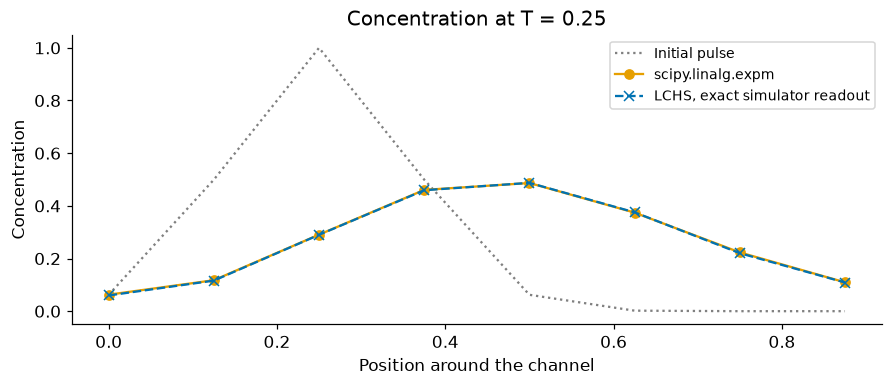

In [3]:
from scipy.linalg import expm

from nwqlib import estimate
from nwqlib.resources import ResourceContext

reference = expm(-FINAL_TIME * A) @ u0                               # the classical answer, used only for comparison
predicted = estimate(selected, context=ResourceContext(basis="cx"))  # counts from the resource laws, no circuit built
show_card(result, reference, u0, predicted, seconds)

**Your own dynamics.** Section 6 has a template cell for any small dense $A$, initial state and constant source, within the limits listed next to it.

## 1. Will it run?

**`plan` decides whether your equation fits before anything is built, and a refusal names the limit to change.**

- **Equation and sign.** NWQLib solves $du/dt=-Au+b$. For an equation written $du/dt=Mu+b$, pass `A = -M`.
- **Dissipation.** LCHS needs the Hermitian part $(A+A^\dagger)/2$ to be positive semidefinite. When it is not, NWQLib adds a multiple $sI$ of the identity that makes it so, and multiplies the answer by the growth factor $e^{sT}$.
- **Input.** A square NumPy array $A$, real or complex, an initial state and an optional constant source. The circuit route also accepts a `PeriodicStencil`. A time-dependent $A$ or $b$ is not implemented ([Supply inputs](../docs/inputs.md)).
- **Size.** The circuit has $\lceil\log_2n\rceil$ system qubits for $n$ unknowns, plus an address register that indexes every evolution. `plan` reports the width before anything runs.
- **Output.** `result.solution` is the physical $u(T)$, available from exact simulator readout. Finite-shot runs return one requested quantity instead ([LCHS guide](../docs/algorithms/lchs.md)).

Each planning stage checks its work against a cap set on `LCHS`. The cell sets the quadrature cap to 30,000 units, below what this channel needs. Planning refuses with a `ValueError` that names `max_quadrature_work` and the amount, and the second half of the cell plans again with that amount.

In [4]:
started = perf_counter()
try:
    plan(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=TROTTER_STEPS,
                              max_quadrature_work=30_000), seed=7)
except ValueError as refusal:
    print(f"Refused after {(perf_counter() - started) * 1e3:.1f} ms, before any circuit existed:\n{refusal}")

remedied = plan(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=TROTTER_STEPS,
                                     max_quadrature_work=30_467), seed=7)  # the remedy: the amount the refusal names
show_table([
    ("Quadrature work cap", remedied.method.max_quadrature_work, "The amount the refusal named"),
    ("Nodes k_j", remedied.reconstruction.physical_branches, "The same quadrature as the card"),
    ("Qubits", len(remedied.reconstruction.success_bits) + len(remedied.reconstruction.system_bits),
     "Reported by plan, before building"),
    ("Same selection as the card's plan", remedied.reconstruction.content_id == selected.reconstruction.content_id,
     "Identical nodes, coefficients and circuit choice"),
], headers=("After raising max_quadrature_work", "Value", "Meaning"))

Refused after 0.4 ms, before any circuit existed:
LCHS quadrature selection and construction require 30467 work units, exceeding LCHS.max_quadrature_work=30000. Raise LCHS.max_quadrature_work to at least 30467.


After raising max_quadrature_work,Value,Meaning
Quadrature work cap,"30,467",The amount the refusal named
Nodes k_j,270,The same quadrature as the card
Qubits,12,"Reported by plan, before building"
Same selection as the card's plan,True,"Identical nodes, coefficients and circuit choice"


## 2. What it costs

**`estimate` predicts the quantum ledger before the circuit exists, and the run records the classical ledger.** The quantum ledger counts qubits, gates and shots. The classical ledger counts memory, work and time on this computer.

`estimate` adds up a gate-count formula for each block of the selected construction without building a circuit. `prepare` builds the circuit without running it, and `inspect_resources` compiles a copy with Qiskit. The circuit has more operations than the 100,000 that `inspect_resources` reads by default, so the cell raises `max_operations`.

In [5]:
from nwqlib import prepare

rec = selected.reconstruction
prepared = prepare(selected, progress=False)
with prepared.run:  # the prepared Run holds the circuit until the block ends
    compiled = prepared.inspect_resources(
        transpile_options={"basis_gates": ["cx", "u"], "optimization_level": 1, "seed_transpiler": 7},
        max_operations=200_000)
predicted_cx = quantity(predicted, "cx")
show_table([
    ("Qubits", quantity(predicted, "logical_width", location="logical_device"), compiled["num_qubits"]),
    ("CX gates", f"{predicted_cx:,} ({predicted.quantity('cx').interpretation})", compiled["operations"].get("cx", 0)),
    ("Shots", quantity(predicted, "shots"), "None: exact readout"),
    ("Single-qubit gates", "not predicted", compiled["operations"].get("u", 0)),
    ("Depth", "not predicted", compiled["depth"]),
    ("T gates", "not predicted", "Not in the cx and u basis"),
], headers=("Quantum ledger", "Predicted by estimate", "Compiled circuit"))
print(f"Compiled CX / predicted CX = {compiled['operations'].get('cx', 0) / predicted_cx:.3f} "
      f"(Qiskit optimization level 1).")

Quantum ledger,Predicted by estimate,Compiled circuit
Qubits,12,12
CX gates,"79,712 (estimate)","79,680"
Shots,0,None: exact readout
Single-qubit gates,not predicted,"58,953"
Depth,not predicted,"138,452"
T gates,not predicted,Not in the cx and u basis


Compiled CX / predicted CX = 1.000 (Qiskit optimization level 1).


In [6]:
trace = result.data.trace
show_table([
    ("Memory of the arrays counted before the run", format_bytes(quantity(predicted, "known_memory", location="host")),
     "Not measured"),
    ("Total host memory", "Not predicted: a host workspace of the construction has no byte count", "Not measured"),
    ("Work [units, a planning quantity, not seconds]", quantity(predicted, "construction_work"),
     trace.construction_work_reserved),
    ("Stored run data", "Not predicted", format_bytes(trace.data_bytes)),
    ("Time on this computer", "Not predicted", f"{seconds:.2f} s for plan and solve, "
     f"{sum(event.timing.seconds for event in trace.events):.3f} s of it in the simulator call"),
], headers=("Classical ledger", "Before the run", "Measured or recorded by the run"))

Classical ledger,Before the run,Measured or recorded by the run
Memory of the arrays counted before the run,"114,688 bytes (115 kB)",Not measured
Total host memory,Not predicted: a host workspace of the construction has no byte count,Not measured
"Work [units, a planning quantity, not seconds]","177,910","355,820"
Stored run data,Not predicted,"90,086 bytes (90.1 kB)"
Time on this computer,Not predicted,"2.59 s for plan and solve, 1.356 s of it in the simulator call"


- **Memory.** `estimate` counts the bytes of the arrays whose size it knows. A host workspace of the construction has no byte count, so the total stays unknown.
- **Work.** The two figures are different counts. `estimate` states an upper bound from the resource laws of the selected blocks, and the run records the construction work it charged before execution.
- **Gates.** Nearly all CX gates belong to SELECT, which applies one controlled evolution per node. Go deeper C compares uniform grids, on which SELECT needs one controlled evolution per address bit.
- **Not estimated:** physical qubits, error correction, run time on hardware and price.

## 3. How accurate?

**The error is measured against `scipy.linalg.expm` and set beside the bounds the Plan states.** Each row says which kind of number it is: measured against reference, upper bound, or unavailable with its reason.

Two approximations add up. The **kernel and quadrature** replace an integral by a finite sum, and the **product formula** approximates each evolution. The cell evaluates the same finite sum with exact matrix exponentials on the host, one classical evaluation, which isolates the first.

In [7]:
from nwqlib.algorithms.lchs import LCHSVerification

exact_sum = solve(problem, method=LCHS(hamiltonian_evolution_backend="dense_exact"), execution="classical",
                  progress=False)
relative_error = np.linalg.norm(u - reference) / np.linalg.norm(reference)
quadrature_error = np.linalg.norm(np.asarray(exact_sum.solution) - reference) / np.linalg.norm(reference)
_, facts = result.verify(checks=LCHSVerification(reference="expm", metric="relative_l2"))
terms = {term.name: term.fact.fact for term in selected.error_model.terms}
roundoff, roundoff_reason = result.data.receipts[0].state_error()
success = (np.linalg.norm(u) / (rec.coefficient_l1_norm * np.linalg.norm(u0))) ** 2
show_table([
    ("Relative error ‖u − u_ref‖ / ‖u_ref‖", relative_error, "Measured against reference"),
    ("The same, from result.verify", facts[0].fact.value.value, "Measured against reference by NWQLib's check"),
    ("Absolute error ‖u − u_ref‖", np.linalg.norm(u - reference), "Measured against reference"),
    ("Absolute error of the finite sum", quadrature_error * np.linalg.norm(reference),
     "Measured against reference. Exact exponentials on the host: kernel and quadrature only"),
    ("Kernel truncation error", terms["kernel_approximation"].value.value, "Upper bound from the Plan, absolute"),
    ("Quadrature error", terms["k_quadrature"].value.value, "Upper bound from the Plan, absolute"),
    ("Product-formula error", None, "Unavailable: " + terms["trotter_synthesis"].reason),
    ("Roundoff of the simulated state", roundoff, "Upper bound" if roundoff is not None else "Unavailable: " + roundoff_reason),
    ("Total amount of dye Σu h", (h * u.sum().real, h * reference.sum()), "LCHS / reference. The exact ODE conserves it"),
    ("Success probability", success, "From α and the solution norm. On hardware it sets the repetitions"),
], headers=("Quantity", "Value", "Kind of number"))

Quantity,Value,Kind of number
Relative error ‖u − u_ref‖ / ‖u_ref‖,0.00557,Measured against reference
"The same, from result.verify",0.00557,Measured against reference by NWQLib's check
Absolute error ‖u − u_ref‖,0.00483,Measured against reference
Absolute error of the finite sum,0.000456,Measured against reference. Exact exponentials on the host: kernel and quadrature only
Kernel truncation error,0.00614,"Upper bound from the Plan, absolute"
Quadrature error,0.00488,"Upper bound from the Plan, absolute"
Product-formula error,not available,Unavailable: missing_stage:trotter_synthesis
Roundoff of the simulated state,not available,Unavailable: outside the roundoff derivation: amplitude-derived masses
Total amount of dye Σu h,"0.265, 0.266",LCHS / reference. The exact ODE conserves it
Success probability,0.253,From α and the solution norm. On hardware it sets the repetitions


Most of the error comes from the product formula, for which the Plan states no bound on this route.

**The Trotter steps trade accuracy for circuit size.** Doubling the steps per evolution about doubles the predicted CX count and lowers the error several times. The cell solves the channel once more with 16 steps, one solve in about 4 s. Go deeper B sweeps five step counts.

In [8]:
trotter_runs = {TROTTER_STEPS: result}
trotter_runs[16] = solve(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=16), seed=7,
                         progress=False)
show_table([(count, quantity(estimate(run.plan, context=ResourceContext(basis="cx")), "cx"),
             np.linalg.norm(np.asarray(run.solution) - reference) / np.linalg.norm(reference))
            for count, run in trotter_runs.items()],
           headers=("Trotter steps per evolution", "Predicted CX", "Relative error"))

Trotter steps per evolution,Predicted CX,Relative error
8,"79,712",0.00557
16,"157,888",0.00118


## 4. How large can I go?

**On a laptop the simulator sets the limit. Beyond it, `plan` and `estimate` still give the cost.** The table lists the limits this run had and the channel's use of them.

`solve(..., execution="classical")` with `hamiltonian_evolution_backend="dense_exact"` evaluates the finite sum on the host, for systems too large to simulate. Its plan states the memory and work before anything runs. [Planning at scale](resource_estimation_at_scale.ipynb) plans circuits far beyond any simulator.

In [9]:
limits = trace.limits
host_estimate = estimate(plan(problem, method=LCHS(hamiltonian_evolution_backend="dense_exact"),
                              execution="classical", seed=7))  # nothing runs yet
show_table([
    ("Qubits the local simulator accepts", limits.max_simulation_qubits,
     f"Default. This channel uses {len(rec.success_bits) + len(rec.system_bits)}"),
    ("Simulator memory cap", f"{limits.simulator_memory_mb:,} MB", "Default simulator_memory_mb"),
    ("SELECT construction work cap", selected.method.max_select_work, "Default max_select_work"),
    ("Host evaluation: memory of its arrays", format_bytes(quantity(host_estimate, "known_memory", location="host")),
     "Stated by plan before it runs"),
    ("Host evaluation: work", quantity(host_estimate, "classical_work"),
     f"Units, a planning quantity, not seconds. {host_estimate.quantity('classical_work').interpretation.replace('_', ' ')}"),
], headers=("Limit or cost", "Value", "Meaning"))

Limit or cost,Value,Meaning
Qubits the local simulator accepts,20,Default. This channel uses 12
Simulator memory cap,"1,024 MB",Default simulator_memory_mb
SELECT construction work cap,"100,000,000",Default max_select_work
Host evaluation: memory of its arrays,"6,400 bytes (6.4 kB)",Stated by plan before it runs
Host evaluation: work,"1,751,800","Units, a planning quantity, not seconds. upper bound"


## 5. What does it assume?

**The runs are noiseless, and every count is a logical count.** The circuit is read out exactly, or sampled with finite shots without noise. A finite-shot request runs with a noise model on the local simulator ([Local Aer](../docs/aer.md)), and [Choose a backend](../docs/backends.md) lists the other backends.

## 6. Your own dynamics

The cell below is the whole workflow without the channel. It solves a damped, driven oscillator $\ddot x+\gamma\dot x+\omega^2x=f$, written for $u=(\omega x,\dot x)$ as $du/dt=-Au+b$. Replace `my_A`, `my_u0`, `my_b` and `my_time` to solve your own system.

- **Input.** `my_A` is a square NumPy array, real or complex, and `my_u0` and `my_b` vectors of the same length. The source is constant in time, and `source=None` removes it.
- **Source.** A source adds the integral $\int_0^Te^{-A(T-s)}b\,ds$, which LCHS evaluates at `duhamel_nodes` quadrature times. Each time takes one more copy of the nodes, so the address register grows with them.
- **Size limits.** The circuit must stay within the simulator's 20 qubits. With the default of 8 quadrature times this 2 × 2 system needs 13 qubits, and the cell's 4 times give 12.
- **Output.** `my_result.solution` is the physical $u(T)$ with its norm and phase, read out exactly by the simulator.

In [10]:
import numpy as np
from scipy.linalg import expm

from nwqlib import LinearDynamics, plan, solve
from nwqlib.algorithms import LCHS

omega, damping, force = 2.0, 0.4, 0.5
my_A = np.array([[0.0, -omega], [omega, damping]])  # your matrix, for du/dt = -A u + b
my_u0 = np.array([omega * 1.0, 0.0])               # your initial state, here x = 1 at rest
my_b = np.array([0.0, force])                      # your constant source, or None
my_time = 1.0

my_problem = LinearDynamics(A=my_A, initial_state=my_u0, time=my_time, source=my_b)
my_plan = plan(my_problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=8, duhamel_nodes=4),
               seed=7)  # nothing runs yet
print(f"{my_plan.reconstruction.physical_branches} evolutions, "
      f"{len(my_plan.reconstruction.success_bits) + len(my_plan.reconstruction.system_bits)} qubits")

my_result = solve(my_plan, progress=False)
my_u = np.asarray(my_result.solution)
propagator = expm(-my_A * my_time)
my_reference = propagator @ my_u0 + np.linalg.solve(my_A, (np.eye(len(my_u0)) - propagator) @ my_b)  # A invertible
print(f"relative error {np.linalg.norm(my_u - my_reference) / np.linalg.norm(my_reference):.2%}")

1040 evolutions, 12 qubits


relative error 0.22%


## 7. What NWQLib adds

- **Planning beyond simulation.** `plan` and `estimate` work at sizes no simulator holds ([Planning at scale](resource_estimation_at_scale.ipynb)).
- **The law behind every number.** Each predicted count comes from a gate-count formula per block ([Mathematics](../docs/mathematics.md)). Section 2 sets it beside the compiled circuit, and the resource notebook compares the formulas with compiled circuits at small sizes.
- **Arguments switch the kernel and the evaluation.** `LCHS(lchs_kernel=..., k_quadrature=...)` selects another published kernel with a quadrature it accepts (Go deeper C). `hamiltonian_evolution_backend="dense_exact"` with `execution="classical"` evaluates the same problem on the host (Section 3).
- **Saved and reloaded.** A saved result reloads with its plan, and its numbers can be recomputed from it (Appendix B).

[Why NWQLib](../docs/why_nwqlib.md) compares this workflow with other packages.

## Go deeper

### A. The channel as a linear ODE, and what `plan` selected

**How does the flow become $du/dt=-Au$, and what did `plan` choose?** This section draws the inputs and reads the Plan, and runs no solve.

On a ring of `POINTS` grid points with spacing $h$, let $S$ shift every value one point downstream. Upwind differences for the transport $c\,\partial_xu$ and central differences for the diffusion $\nu\,\partial_{xx}u$ give

$$A=\frac{c}{h}(I-S)-\frac{\nu}{h^2}\left(S+S^{\mathsf T}-2I\right)=L+iH.$$

The Hermitian part $L=(A+A^\dagger)/2$ is the diffusion. It is positive semidefinite, so it can only damp. The anti-Hermitian part $iH$, with Hermitian $H$, is the transport, which moves the pulse without changing its norm.

The upwind scheme keeps concentrations nonnegative but adds a numerical diffusion $ch/2$, larger than the physical $\nu$ on this grid (table). Most of the spreading in the plots is therefore a grid effect. Doubling `POINTS` halves it and costs one more system qubit.

Quantity,Value,Meaning
Grid points / system qubits,"8, 3",One amplitude per grid point
Smallest eigenvalue of L,-1.39e-15,Zero up to roundoff: diffusion never amplifies
"Spectral norms ‖L‖, ‖H‖","18.6, 8","Rates of diffusion and transport, 1/time"
Physical / numerical diffusion,"0.01, 0.0625","ν and c h / 2, channel lengths squared per time"
Norm ‖u(0)‖ → ‖u(T)‖,"1.23, 0.868",Diffusion removes the difference


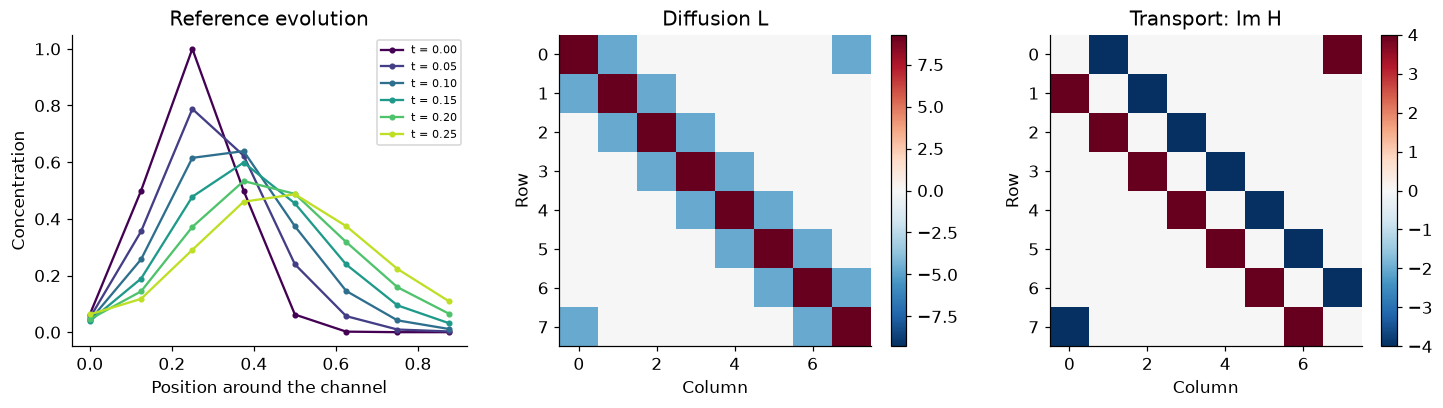

In [11]:
L = (A + A.conj().T) / 2
H = (A - A.conj().T) / 2j
show_table([
    ("Grid points / system qubits", (POINTS, int(np.log2(POINTS))), "One amplitude per grid point"),
    ("Smallest eigenvalue of L", np.linalg.eigvalsh(L).min(), "Zero up to roundoff: diffusion never amplifies"),
    ("Spectral norms ‖L‖, ‖H‖", (np.linalg.norm(L, 2), np.linalg.norm(H, 2)), "Rates of diffusion and transport, 1/time"),
    ("Physical / numerical diffusion", (DIFFUSIVITY, SPEED * h / 2), "ν and c h / 2, channel lengths squared per time"),
    ("Norm ‖u(0)‖ → ‖u(T)‖", (np.linalg.norm(u0), np.linalg.norm(reference)), "Diffusion removes the difference"),
])

dense_times = np.linspace(0, FINAL_TIME, 6)
fig, axes = plt.subplots(1, 3, figsize=(13, 3.6), layout="constrained")
for time, color in zip(dense_times, plt.cm.viridis(np.linspace(0, 0.9, len(dense_times))), strict=True):
    axes[0].plot(x, (expm(-time * A) @ u0), "o-", color=color, markersize=3, label=f"t = {time:.2f}")
axes[0].set(xlabel="Position around the channel", ylabel="Concentration", title="Reference evolution")
axes[0].legend(fontsize=7)
for ax, matrix, title in ((axes[1], L, "Diffusion L"), (axes[2], H.imag, "Transport: Im H")):
    scale = np.abs(matrix).max()
    image = ax.imshow(matrix.real, cmap="RdBu_r", vmin=-scale, vmax=scale)
    ax.set(title=title, xlabel="Column", ylabel="Row")
    fig.colorbar(image, ax=ax)
plt.show()

LCHS writes the non-unitary $e^{-AT}$ as a weighted sum of unitary evolutions, each of which a quantum computer can simulate:

$$e^{-AT}=\int_{\mathbb R}\frac{f(k)}{1-ik}\,e^{-i(kL+H)T}\,dk\;\approx\;\sum_j c_j\,e^{-i(k_jL+H)T}.$$

The **kernel** $f(k)$ decides how fast the integrand decays, and the **quadrature** chooses the nodes $k_j$. The normalization $\alpha=\sum_j|c_j|$ sets the success probability $p=\left(\|u(T)\|/(\alpha\|u(0)\|)\right)^2$, so a kernel with a smaller $\alpha$ needs fewer repetitions. The table reads these choices from the Plan.

<details><summary>The identity, the coefficients and the circuit</summary>

The identity is Eq. (6) of An, Childs and Lin, *Commun. Math. Phys.* **407**, 19 (2026), [arXiv:2312.03916v2](https://arxiv.org/abs/2312.03916v2), and holds when $L$ is positive semidefinite. With quadrature weights $w_j$, the LCHS coefficients are $c_j=w_jf(k_j)/(1-ik_j)$ (their Eq. (61)).

The circuit combines the terms as a linear combination of unitaries. PREP loads the amplitudes $\sqrt{|c_j|/\alpha}$ on an address register, SELECT applies the evolution chosen by the address, and PREP is undone.

Each evolution $e^{-i(k_jL+H)T}$ is built from `TROTTER_STEPS` steps of a second-order product formula over the Pauli terms of $L$ and $H$.

</details>

Quantity,Value,Meaning
Kernel / quadrature,"near_optimal_eq7, composite_gauss",Selected from approximation_tolerance
Nodes k_j,270,From -27.5 to 27.5
Normalization α,1.4,"Sum of |c_j|, dimensionless"
Qubits,12,3 system qubits and 9 address qubits
SELECT implementation,multiplexor,How the address register controls the evolutions


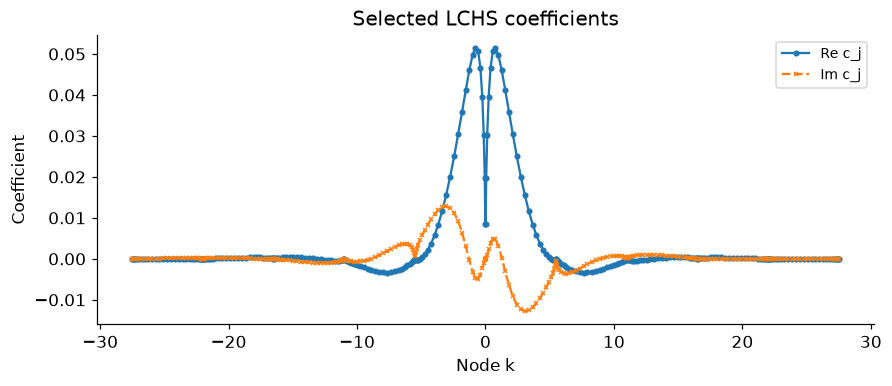

In [12]:
from nwqlib.algorithms.lchs import resolve_lchs_coefficient_plan

coefficients = resolve_lchs_coefficient_plan(selected)
nodes, values = np.asarray(coefficients.nodes), np.asarray(coefficients.coefficients)
show_table([
    ("Kernel / quadrature", (coefficients.resolved_lchs_kernel.implementation,
                             coefficients.resolved_k_quadrature.implementation), "Selected from approximation_tolerance"),
    ("Nodes k_j", len(nodes), f"From {nodes.min():.3g} to {nodes.max():.3g}"),
    ("Normalization α", rec.coefficient_l1_norm, "Sum of |c_j|, dimensionless"),
    ("Qubits", len(rec.success_bits) + len(rec.system_bits),
     f"{len(rec.system_bits)} system qubits and {len(rec.success_bits)} address qubits"),
    ("SELECT implementation", rec.selected_select, "How the address register controls the evolutions"),
])

order = np.argsort(nodes)
fig, ax = plt.subplots(figsize=(8, 3.4), layout="constrained")
ax.plot(nodes[order], values.real[order], "o-", markersize=3, label="Re c_j")
ax.plot(nodes[order], values.imag[order], "x--", markersize=3, label="Im c_j")
ax.set(xlabel="Node k", ylabel="Coefficient", title="Selected LCHS coefficients")
ax.legend(fontsize=9)
plt.show()

### B. Trotter steps against quadrature

**Which of the two approximations should you refine?** The cell repeats the channel solve with 1 to 16 product-formula steps per evolution, three new solves in about 2 s, each read out exactly.

As the step count grows, the quantum result approaches the exact-exponential finite sum of Section 3, whose error more steps cannot reduce.

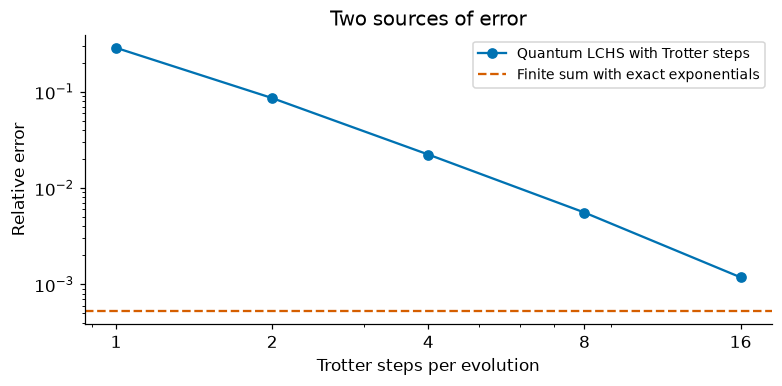

In [13]:
steps = (1, 2, 4, 8, 16)
for count in steps:
    if count not in trotter_runs:
        trotter_runs[count] = solve(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=count),
                                    seed=7, progress=False)
trotter_errors = [np.linalg.norm(np.asarray(trotter_runs[count].solution) - reference) / np.linalg.norm(reference)
                  for count in steps]

fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
ax.loglog(steps, trotter_errors, "o-", color="#0072B2", label="Quantum LCHS with Trotter steps")
ax.axhline(quadrature_error, color="#D55E00", linestyle="--", label="Finite sum with exact exponentials")
ax.set(xlabel="Trotter steps per evolution", ylabel="Relative error", xticks=steps, xticklabels=steps,
       title="Two sources of error")
ax.legend(fontsize=9)
plt.show()

The product-formula error dominates at every step count shown, so for this example the evolution is the approximation to refine. It falls about fourfold per doubling of the steps, as expected for a second-order formula.

### C. Three kernels

**How do the kernel and the grid change the gate count, the success probability and the error?** The cell plans and solves four constructions on the circuit and evaluates each finite sum with exact exponentials, eight solves in about 3 s.

- `near_optimal_eq7`, the default kernel of An, Childs and Lin (Eq. (7) of arXiv:2312.03916v2, with $\beta=0.75$), with Gauss quadrature on panels. Its coefficients decay almost exponentially in $|k|$.
- `cauchy_density`, the original kernel of An, Liu and Lin ([*Phys. Rev. Lett.* **131**, 150603 (2023)](https://doi.org/10.1103/PhysRevLett.131.150603)), whose slowly decaying tails need a wide $k$ range.
- `low_somma_f2`, the Fourier kernel of Low and Somma ([arXiv:2508.19238v2](https://arxiv.org/abs/2508.19238v2), Eq. (6) with $j=2$, $y=1$) with the trapezoidal rule of their Theorem 3.

On a uniform grid of $2^m$ nodes, SELECT needs one controlled evolution per address bit in each product-formula step instead of one per node. The table compares the default Gauss grid with a 6-qubit uniform grid and adds the other two kernels.

<details><summary>The kernels' integrands and why a uniform grid is cheaper</summary>

The Cauchy kernel's integrand factor $f(k)/(1-ik)$ is $1/(\pi(1+k^2))$ (restated as Eq. (5) of arXiv:2312.03916v2). The Low–Somma identity is approximate (their Theorem 1, Eq. (8)), and its error is part of the kernel bound.

On a uniform grid, $k_j$ is a binary number. Within each product-formula step of length $\Delta t$, the factor $e^{-ik_jL\Delta t}$ then becomes a product of controlled evolutions, one per address bit.

</details>

Kernel and grid,Nodes,Predicted CX,α,Success probability,SELECT,"Error, exact exponentials","Error, quantum"
"An–Childs–Lin, Gauss (default)",270,"79,712",1.4,0.253,multiplexor,0.000526,0.00557
"An–Childs–Lin, uniform grid",64,"1,408",1.31,0.305,structured,0.0377,0.0267
"Cauchy, uniform grid",64,"1,408",0.921,0.526,structured,0.0696,0.069
"Low–Somma, trapezoid",97,"20,192",2.14,0.109,multiplexor,3e-05,0.00577


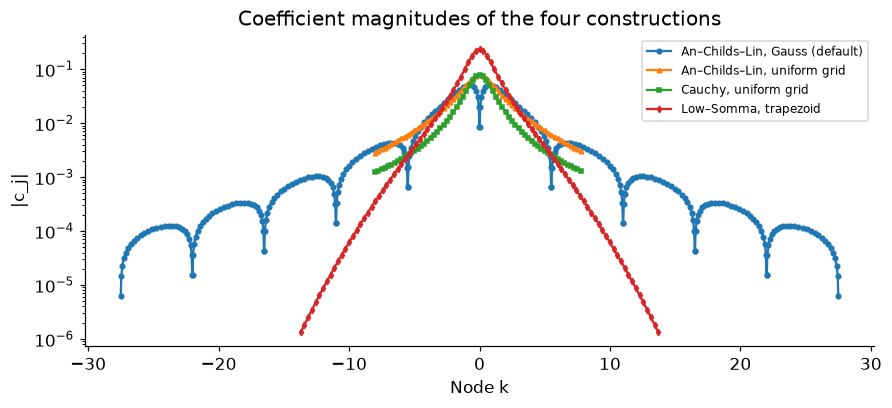

In [14]:
from nwqlib.algorithms.lchs import ProviderConfig

# A uniform grid on 6 address qubits has the 64 nodes k = j * 2**-2 for the integers j from -32 to 31,
# so k runs from -8 to 7.75 in steps of 0.25.
uniform = ProviderConfig(implementation="signed_binary_uniform", parameters={"num_qubits": 6, "lsb_position": -2})
choices = {
    "An–Childs–Lin, Gauss (default)": {},
    "An–Childs–Lin, uniform grid": {"k_quadrature": uniform},
    "Cauchy, uniform grid": {"lchs_kernel": "cauchy_density", "k_quadrature": uniform},
    "Low–Somma, trapezoid": {"lchs_kernel": "low_somma_f2", "k_quadrature": "symmetric_uniform_trapezoid"},
}
rows, kernel_coefficients = [], {}
for label, options in choices.items():
    candidate = plan(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=TROTTER_STEPS,
                                          **options), seed=7)
    run = solve(candidate, progress=False)
    exact = solve(problem, method=LCHS(hamiltonian_evolution_backend="dense_exact", **options),
                  execution="classical", progress=False)
    solution = np.asarray(run.solution)
    alpha = candidate.reconstruction.coefficient_l1_norm
    selected_coefficients = resolve_lchs_coefficient_plan(candidate)
    kernel_coefficients[label] = (np.asarray(selected_coefficients.nodes),
                                  np.asarray(selected_coefficients.coefficients))
    rows.append((label, len(selected_coefficients.nodes),
                 quantity(estimate(candidate, context=ResourceContext(basis="cx")), "cx"), alpha,
                 (np.linalg.norm(solution) / (alpha * np.linalg.norm(u0))) ** 2,
                 candidate.reconstruction.selected_select,
                 np.linalg.norm(np.asarray(exact.solution) - reference) / np.linalg.norm(reference),
                 np.linalg.norm(solution - reference) / np.linalg.norm(reference)))
show_table(rows, headers=("Kernel and grid", "Nodes", "Predicted CX", "α", "Success probability", "SELECT",
                          "Error, exact exponentials", "Error, quantum"))

fig, ax = plt.subplots(figsize=(8, 3.6), layout="constrained")
for (label, (k, c)), marker in zip(kernel_coefficients.items(), "o^sd", strict=True):
    order = np.argsort(k)
    ax.semilogy(k[order], np.abs(c[order]), marker + "-", markersize=3, label=label)
ax.set(xlabel="Node k", ylabel="|c_j|", title="Coefficient magnitudes of the four constructions")
ax.legend(fontsize=8)
plt.show()

The uniform grids use the structured SELECT and cut the predicted CX count many times, at a cost in accuracy, which grows most for the Cauchy kernel.

Cauchy has the smallest α and the highest success probability. Low–Somma has the smallest finite-sum error but the largest α and the lowest success probability.

### D. Loading the coefficient and initial states

**Can an approximate loader replace exact state preparation?** The first cell compiles an exact loader and two matrix-product-state (MPS) loaders for six coefficient states, and the second solves the channel with five state-preparation choices, together about 3 s.

Exact loading of an arbitrary $m$-qubit state needs a CX count that doubles with every qubit. An MPS of small bond dimension loads a smooth vector, such as the LCHS coefficient magnitudes or the initial pulse, with a CX count that grows only linearly in $m$.

The cell compares both for the An–Childs–Lin coefficients on uniform grids of 5 to 9 qubits, with $k$ in $[-16,16)$, and for the 270 Gauss coefficients of the default plan. The infidelity is one minus the squared overlap with the exact target.

Coefficients,Address qubits,MPS layers,Exact loading CX,MPS CX,MPS infidelity
Uniform grid,5,2,26,19,0.000132
Uniform grid,5,4,26,40,1.61e-05
Uniform grid,6,2,57,26,0.000304
Uniform grid,6,4,57,47,0.000117
Uniform grid,7,2,120,27,0.000322
Uniform grid,7,4,120,57,0.000133
Uniform grid,8,2,247,37,0.000314
Uniform grid,8,4,247,73,0.000106
Uniform grid,9,2,502,41,0.000309
Uniform grid,9,4,502,79,0.000113


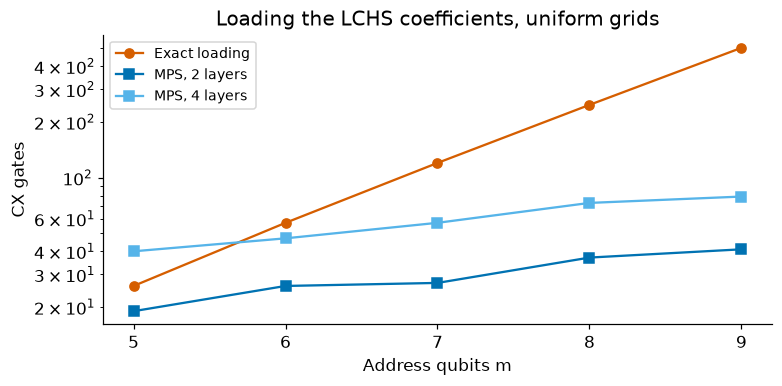

In [15]:
from qiskit import QuantumCircuit, transpile
from qiskit.circuit.library import StatePreparation

from nwqlib.subroutines.state_preparation import (build_mps_circuit_state_preparation,
                                                  validate_mps_circuit_state_preparation)

rows = []


def compare_loaders(label, target):
    """Compile exact loading and two- and four-layer MPS loading of one coefficient state."""
    qubits = int(np.log2(len(target)))
    loader = QuantumCircuit(qubits)
    loader.append(StatePreparation(target), range(qubits))
    exact_cx = transpile(loader, basis_gates=["cx", "u"], optimization_level=1, seed_transpiler=7).count_ops()["cx"]
    for layers in (2, 4):
        mps = validate_mps_circuit_state_preparation(build_mps_circuit_state_preparation(target, num_layers=layers))
        mps_cx = transpile(mps.circuit, basis_gates=["cx", "u"], optimization_level=1,
                           seed_transpiler=7).count_ops()["cx"]
        rows.append((label, qubits, layers, exact_cx, mps_cx, 1 - mps.fidelity_to_target))


for qubits in range(5, 10):
    grid = ProviderConfig(implementation="signed_binary_uniform",
                          parameters={"num_qubits": qubits, "lsb_position": 5 - qubits})  # spacing 2**(5 - qubits)
    compare_loaders("Uniform grid", resolve_lchs_coefficient_plan(problem, k_quadrature=grid).prep_amplitudes())
compare_loaders("Gauss grid", coefficients.prep_amplitudes())  # the 270 coefficients of Go deeper A
show_table(rows, headers=("Coefficients", "Address qubits", "MPS layers", "Exact loading CX", "MPS CX", "MPS infidelity"))

table = np.array([row[1:] for row in rows if row[0] == "Uniform grid"])
fig, ax = plt.subplots(figsize=(7, 3.4), layout="constrained")
two = table[table[:, 1] == 2]
ax.semilogy(two[:, 0], two[:, 2], "o-", color="#D55E00", label="Exact loading")
for layers, color in ((2, "#0072B2"), (4, "#56B4E9")):
    subset = table[table[:, 1] == layers]
    ax.semilogy(subset[:, 0], subset[:, 3], "s-", color=color, label=f"MPS, {layers} layers")
ax.set(xlabel="Address qubits m", ylabel="CX gates", xticks=two[:, 0], title="Loading the LCHS coefficients, uniform grids")
ax.legend(fontsize=9)
plt.show()

In the full algorithm, `lcu_state_preparation="mps_circuit"` loads the coefficients with an MPS circuit, `initial_state_preparation="mps_circuit"` does the same for $u(0)$, and `mps_num_layers` sets the coefficient loader's layers. The cell uses a 5-qubit uniform grid on $[-8,8)$ and repeats the default Gauss grid with MPS-loaded coefficients.

In [16]:
mps_coefficients = {"lcu_state_preparation": "mps_circuit"}
mps_uniform = ProviderConfig(implementation="signed_binary_uniform", parameters={"num_qubits": 5, "lsb_position": -1})
cases = (
    ("Uniform grid", "Exact loading for both", {"k_quadrature": mps_uniform}),
    ("Uniform grid", "MPS for the coefficients, 2 layers", {"k_quadrature": mps_uniform, **mps_coefficients}),
    ("Uniform grid", "MPS for the coefficients, 4 layers",
     {"k_quadrature": mps_uniform, **mps_coefficients, "mps_num_layers": 4}),
    ("Uniform grid", "MPS for the initial pulse", {"k_quadrature": mps_uniform, "initial_state_preparation": "mps_circuit"}),
    ("Gauss grid", "MPS for the coefficients, 2 layers", mps_coefficients),
)
rows = [("Gauss grid", "Exact loading for both", relative_error)]
for grid_label, label, options in cases:
    run = solve(problem, method=LCHS(hamiltonian_evolution_backend="trotter", trotter_steps=TROTTER_STEPS, **options),
                seed=7, progress=False)
    rows.append((grid_label, label, np.linalg.norm(np.asarray(run.solution) - reference) / np.linalg.norm(reference)))
show_table(rows, headers=("Quadrature", "State preparation", "Relative error"))

Quadrature,State preparation,Relative error
Gauss grid,Exact loading for both,0.00557
Uniform grid,Exact loading for both,0.0269
Uniform grid,"MPS for the coefficients, 2 layers",0.0273
Uniform grid,"MPS for the coefficients, 4 layers",0.027
Uniform grid,MPS for the initial pulse,0.0269
Gauss grid,"MPS for the coefficients, 2 layers",0.0197


On the uniform grid, MPS loading changes the error by a small fraction of the error the grid itself causes. On the Gauss grid it raises the error several times.

The Gauss coefficients are stored panel by panel, and nearby addresses need not hold nearby $k$ values. The loader therefore sees a less smooth function, as its larger infidelity in the loader table shows.

The loader table counts CX gates for the loaders alone, not for a complete LCHS circuit.

## Appendix

### A. The full resource estimate

Block invocations count the calls of the building blocks: PREP, SELECT, the inverse of PREP and the loading of $u(0)$. The ancilla qubits are the address qubits. The last line names the gate counts that the resource laws of this construction leave unknown.

In [17]:
# Display helpers for Appendix A: labels of the resource metrics and a table of the estimate.
RESOURCE_LABELS = {
    "logical_width": "Qubits", "system": "System qubits", "clean_ancilla": "Ancilla qubits",
    "cx": "CX gates", "calls": "Block invocations", "preparation_components": "Single-qubit factors of product-state loading",
    "known_memory": "Memory of the selected arrays [bytes]",
    "construction_work": "Classical construction work [size units]",
}
UNMODELED_LABELS = {
    "operations": "total gates", "single_qubit": "single-qubit gates", "two_qubit": "two-qubit gates",
    "controlled": "controlled gates", "clifford": "Clifford gates", "t": "T gates", "toffoli": "Toffoli gates",
    "ccz": "CCZ gates", "arbitrary_rotations": "arbitrary rotations", "cx": "CX gates", "logical_depth": "depth",
    "t_depth": "T depth", "non_clifford_depth": "non-Clifford depth", "global_phases": "global phases",
}


def show_estimate(workload):
    """Show the resource quantities an estimate determines, and name the ones its laws do not cover."""
    rows = [(RESOURCE_LABELS[q.metric], q.fact.value.numerator if q.fact.value.kind == "rational" else q.fact.value.value,
             q.interpretation.replace("_", " "))
            for q in workload.quantities if q.metric in RESOURCE_LABELS and q.fact.availability == "concrete"]
    show_table(rows, headers=("Quantity", "Value", "Kind of value"), digits=6)
    missing = sorted({UNMODELED_LABELS[q.metric] for q in workload.quantities
                      if q.metric in UNMODELED_LABELS and q.fact.availability == "unknown"})
    if missing:
        display(HTML("<p>Not covered by the resource laws of this construction: " + escape(", ".join(missing)) + ".</p>"))

In [18]:
show_estimate(predicted)

Quantity,Value,Kind of value
CX gates,"79,712",estimate
Block invocations,4,exact
Single-qubit factors of product-state loading,0,exact
Ancilla qubits,9,exact
Memory of the selected arrays [bytes],"114,688",exact
Qubits,12,exact
System qubits,3,exact
Classical construction work [size units],"177,910",upper bound


### B. A saved result, reloaded and recomputed

`result.save` stores the plan, the selected nodes and coefficients, and the solution. Loading restores them without selecting a new quadrature or running the circuit again. The cell recomputes the card's relative error from the loaded solution and compares the two.

In [19]:
from pathlib import Path
from tempfile import mkdtemp

from nwqlib import load_result

restored = load_result(result.save(Path(mkdtemp()) / "channel-lchs"))
restored_error = np.linalg.norm(np.asarray(restored.solution) - reference) / np.linalg.norm(reference)
show_table([
    ("Relative error, recomputed from the loaded solution", restored_error,
     "Equal to the card's value" if restored_error == relative_error else "Differs from the card's value"),
    ("Nodes of the loaded plan", restored.plan.reconstruction.physical_branches,
     "Equal to the selected nodes" if restored.plan.reconstruction.physical_branches == rec.physical_branches
     else "Differs"),
])
show_table([
    ("Plan identifier", result.plan_id, "The equation, the configured method and the requested output"),
    ("Result identifier", result.content_id, "This solution and the observations it used"),
], details="Identifiers of the saved records")

Quantity,Value,Meaning
"Relative error, recomputed from the loaded solution",0.00557,Equal to the card's value
Nodes of the loaded plan,270,Equal to the selected nodes


Quantity,Value,Meaning
Plan identifier,sha256:3d666d20eb26937c976f30ac8e8ac9162ef5026b60b146ced1aa39a580737e60,"The equation, the configured method and the requested output"
Result identifier,sha256:cc6f9dfd856d7fa7f4b484636fda79e725e29edbff41b81ffbd8a49cd32a972d,This solution and the observations it used
